<a href="https://colab.research.google.com/github/sastha-06/KIC-Phase2/blob/main/DAY_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape of Dataset : (891, 15)

Data Types:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Null Values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Duplicate Rows : 107

Statistical Summary:
           survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN 

/tmp/ipykernel_2339/4193408553.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)
/tmp/ipykernel_2339/4193408553.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

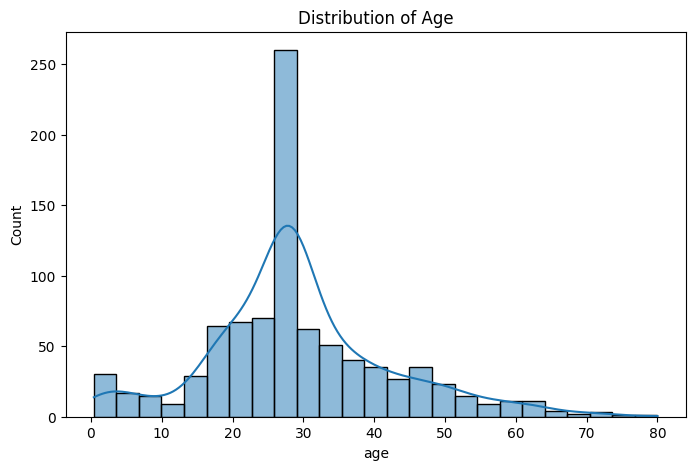

1. Most passengers were between ages 20 and 40.
2. Fewer elderly passengers are present.
3. Age is slightly right-skewed.



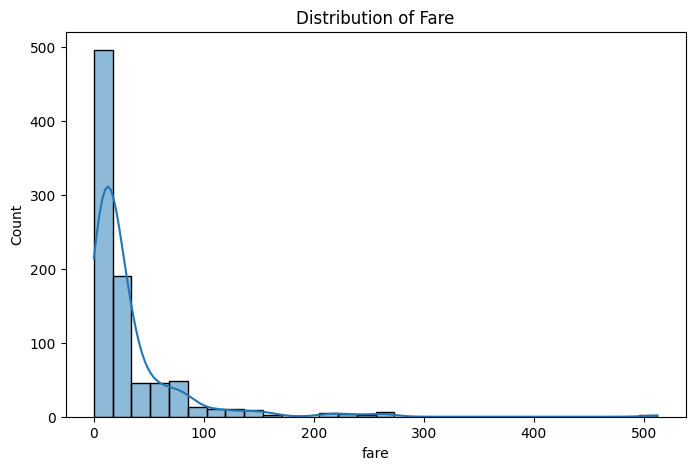

1. Most fares are low-priced tickets.
2. Some extreme high fares create outliers.
3. Fare is strongly right-skewed.



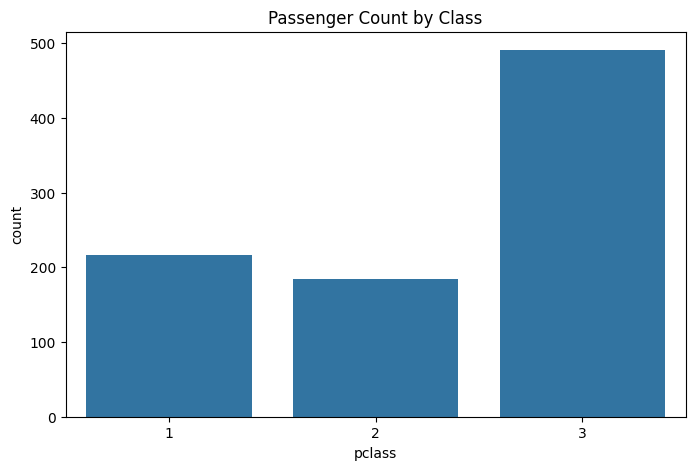

1. Most passengers were in 3rd class.
2. 1st class had fewer passengers.
3. Class may influence survival.



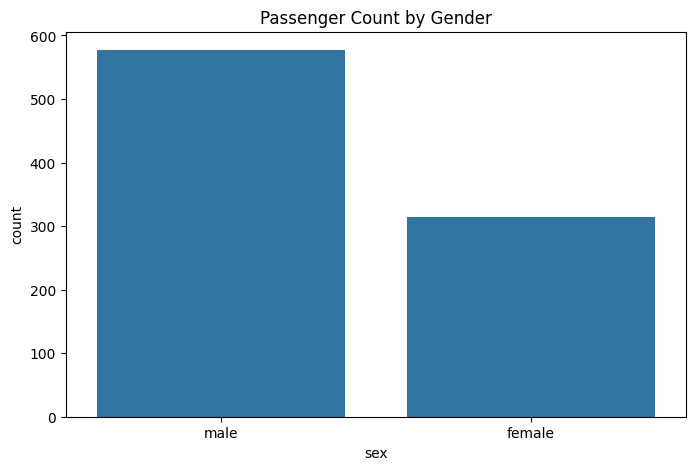

1. Male passengers are higher in count.
2. Gender imbalance exists.
3. Gender may be useful for prediction.



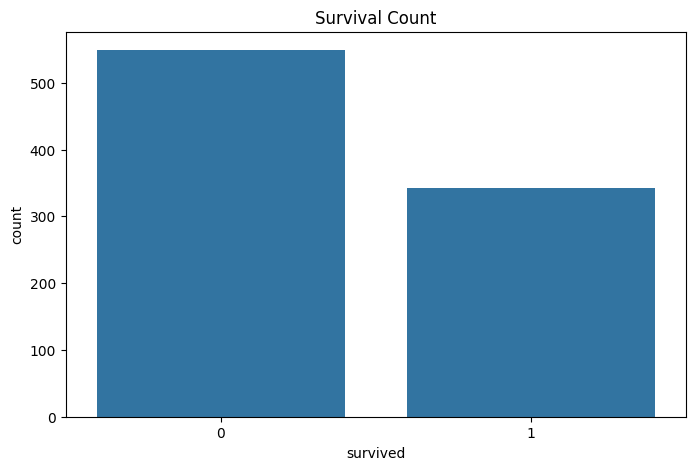

1. More passengers died than survived.
2. Classes are moderately imbalanced.
3. Target balancing may help modeling.



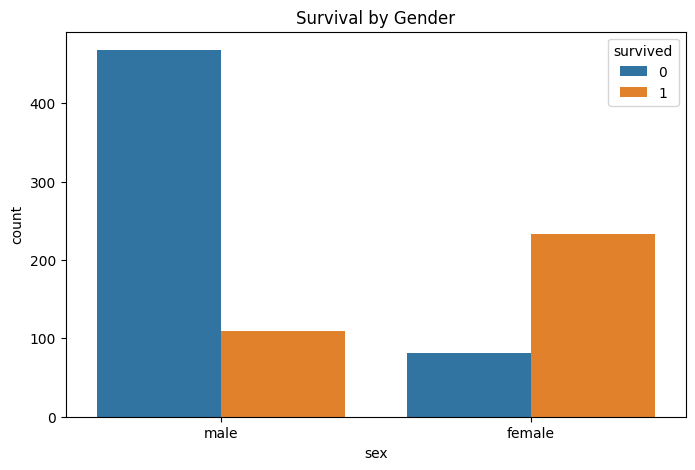

1. Females survived more often than males.
2. Male deaths are significantly higher.
3. Sex is a strong predictor.



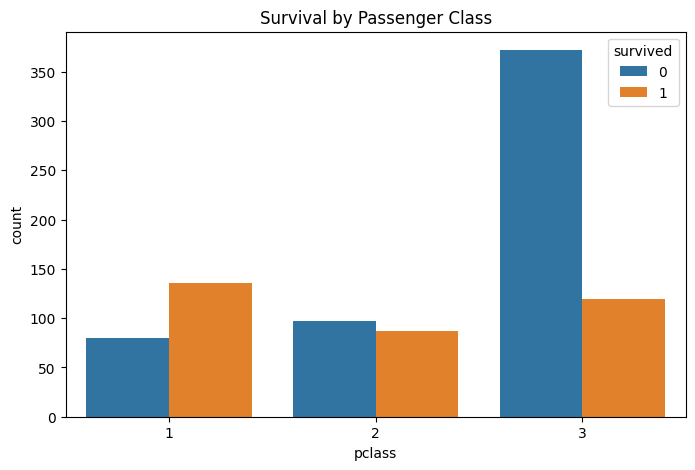

1. 1st class had highest survival.
2. 3rd class had highest deaths.
3. Class strongly affects outcome.



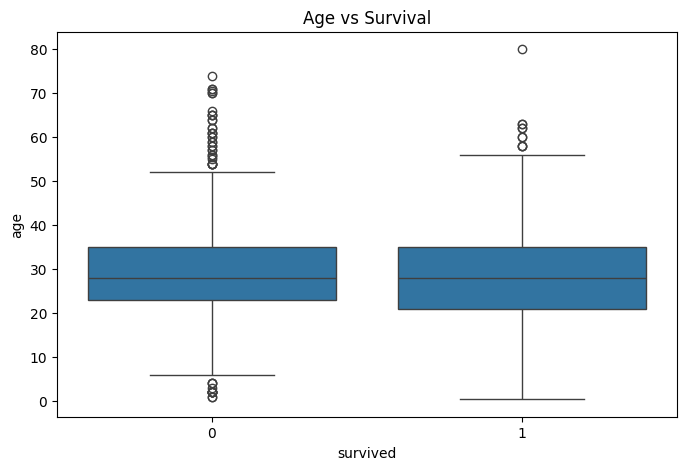

1. Younger passengers show slightly better survival.
2. Age overlap is high across groups.
3. Age alone is not enough.



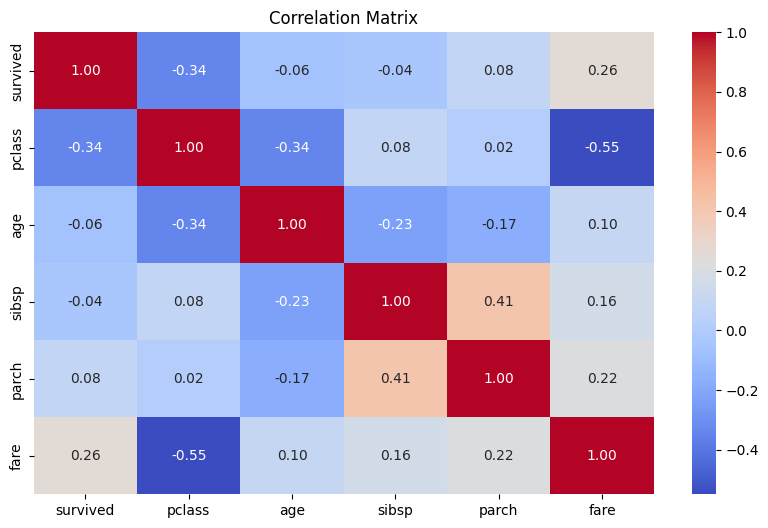

1. Survival relates with class and fare.
2. No severe multicollinearity found.
3. Numeric variables are usable.



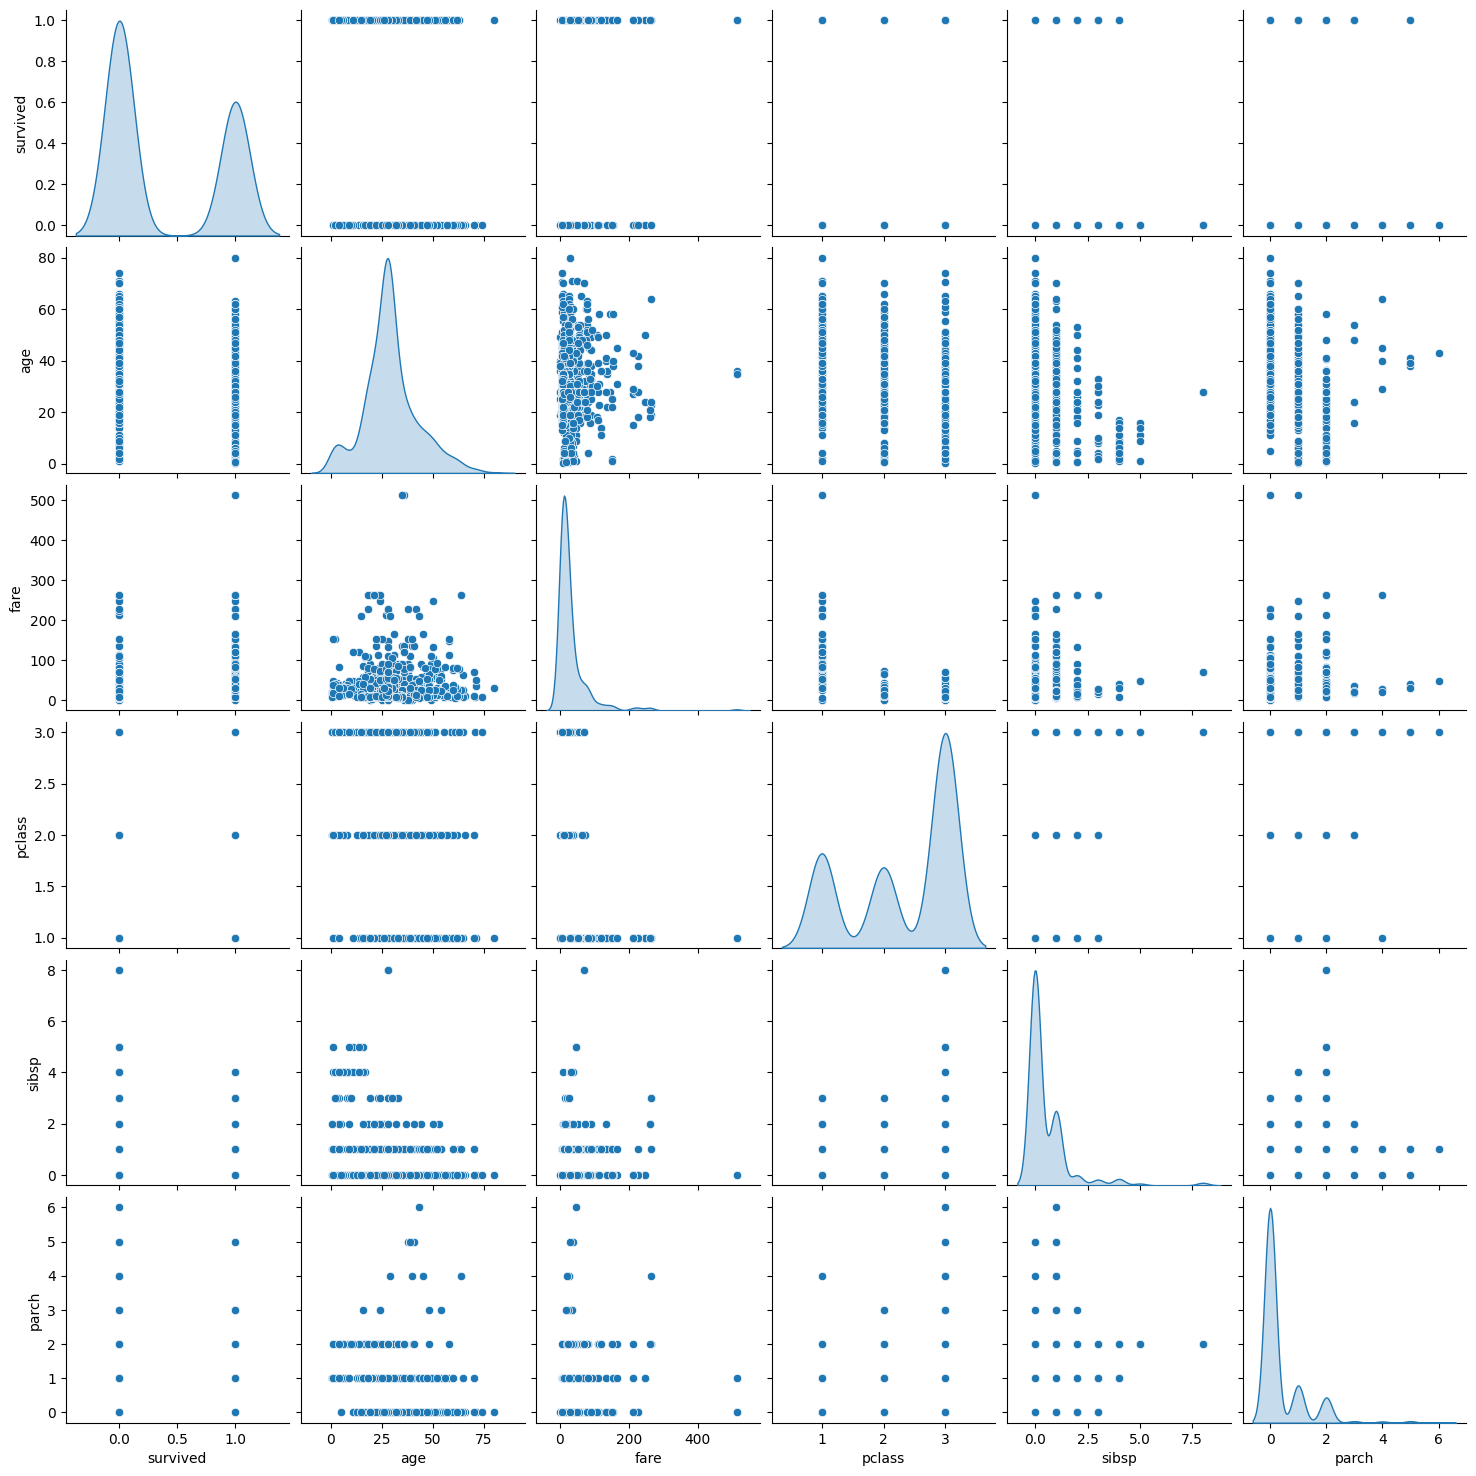

1. Fare outliers are visible.
2. Lower class values show more survivors.
3. Age patterns are mixed.

Candidate Features:
['sex', 'pclass', 'fare', 'age', 'embarked', 'sibsp', 'parch', 'family_size', 'alone']

Drop Columns:
['deck', 'alive', 'who', 'adult_male', 'embark_town']


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

print("Shape of Dataset :", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nDuplicate Rows :", df.duplicated().sum())
print("\nStatistical Summary:\n", df.describe(include="all"))

# BASIC CLEANING
df["age"].fillna(df["age"].median(), inplace=True)
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)
df["fare"].fillna(df["fare"].median(), inplace=True)

# UNIVARIATE ANALYSIS

plt.figure(figsize=(8,5))
sns.histplot(df["age"], kde=True, bins=25)
plt.title("Distribution of Age")
plt.show()

print("1. Most passengers were between ages 20 and 40.")
print("2. Fewer elderly passengers are present.")
print("3. Age is slightly right-skewed.\n")

plt.figure(figsize=(8,5))
sns.histplot(df["fare"], kde=True, bins=30)
plt.title("Distribution of Fare")
plt.show()

print("1. Most fares are low-priced tickets.")
print("2. Some extreme high fares create outliers.")
print("3. Fare is strongly right-skewed.\n")

plt.figure(figsize=(8,5))
sns.countplot(x="pclass", data=df)
plt.title("Passenger Count by Class")
plt.show()

print("1. Most passengers were in 3rd class.")
print("2. 1st class had fewer passengers.")
print("3. Class may influence survival.\n")

plt.figure(figsize=(8,5))
sns.countplot(x="sex", data=df)
plt.title("Passenger Count by Gender")
plt.show()

print("1. Male passengers are higher in count.")
print("2. Gender imbalance exists.")
print("3. Gender may be useful for prediction.\n")

# BIVARIATE ANALYSIS

plt.figure(figsize=(8,5))
sns.countplot(x="survived", data=df)
plt.title("Survival Count")
plt.show()

print("1. More passengers died than survived.")
print("2. Classes are moderately imbalanced.")
print("3. Target balancing may help modeling.\n")

plt.figure(figsize=(8,5))
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Survival by Gender")
plt.show()

print("1. Females survived more often than males.")
print("2. Male deaths are significantly higher.")
print("3. Sex is a strong predictor.\n")

plt.figure(figsize=(8,5))
sns.countplot(x="pclass", hue="survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

print("1. 1st class had highest survival.")
print("2. 3rd class had highest deaths.")
print("3. Class strongly affects outcome.\n")

plt.figure(figsize=(8,5))
sns.boxplot(x="survived", y="age", data=df)
plt.title("Age vs Survival")
plt.show()

print("1. Younger passengers show slightly better survival.")
print("2. Age overlap is high across groups.")
print("3. Age alone is not enough.\n")

# MULTIVARIATE ANALYSIS

plt.figure(figsize=(10,6))
num_df = df.select_dtypes(include=np.number)
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

print("1. Survival relates with class and fare.")
print("2. No severe multicollinearity found.")
print("3. Numeric variables are usable.\n")

sns.pairplot(df[["survived","age","fare","pclass","sibsp","parch"]],diag_kind='kde')
plt.show()

print("1. Fare outliers are visible.")
print("2. Lower class values show more survivors.")
print("3. Age patterns are mixed.\n")

# FEATURE ENGINEERING
df["family_size"] = df["sibsp"] + df["parch"] + 1

print("Candidate Features:")
print(["sex","pclass","fare","age","embarked","sibsp","parch","family_size","alone"])

print("\nDrop Columns:")
print(["deck","alive","who","adult_male","embark_town"])